<a href="https://colab.research.google.com/github/Rania0361/Final-Year-Project/blob/main/src/GA/multi-GA/Exact-Fidelity-GA/NSGA_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***NSGA-II : Multi-Objective Genetic Algorithm***
This section implements **NSGA-II (Non-dominated Sorting Genetic Algorithm II)**, a multi-objective extension of the previous single-objective GA. Instead of optimizing fidelity alone, NSGA-II simultaneously optimizes **three competing objectives**:
- **Maximize fidelity** : how closely the circuit matches the target unitary.
- **Minimize circuit cost** : a weighted sum of gate costs reflecting hardware complexity.
- **Minimize circuit depth** : the number of sequential layers in the circuit, directly impacting execution time and noise accumulation on real hardware.


# *Qiskit Installation*

In [1]:
pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00


# *Pylatexenc Installation*

In [2]:
pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=00d9e3ad97a02e7012bddac21bc489c540bf0dc005aa10ed15879dba0fdb5869
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


# *Matplotlib Installation*

In [3]:
pip install matplotlib

# Imports
This section imports all the libraries required to run the project.

In [4]:
## Imports
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
import matplotlib.pyplot as plt
import copy
import random
from joblib import Parallel, delayed
import time
import math
from numpy import pi

## ***Gate Cost Dictionary***
This section defines `GATE_COSTS`, a dictionary that assigns a **hardware complexity cost** to each gate type. These costs reflect the relative difficulty of implementing each gate on real quantum hardware — multi-qubit gates like `Toffoli`, `Fredkin`, and `Miller` are significantly more expensive than single-qubit gates.

In [5]:
# -------------------- Configuration des seeds --------------------
# utiliser seed pour assurer la génération de même suite de nombres aléatoires
def set_random_seeds(seed=42):
    """Configure toutes les graines aléatoires pour la reproductibilité."""
    np.random.seed(seed)
    random.seed(seed)
    # Pour matplotlib (si nécessaire pour les couleurs aléatoires)
    plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.Set1.colors)

    print(f" Seeds configurées: {seed}")

# -------------------- Coûts des portes --------------------
GATE_COSTS = {
    'NOT': 1,
    'Phase': 1,
    'H': 2,      # Hadamard
    'X': 1,
    'Y': 1,
    'Z': 1,
    'CX': 5,     # Équivalent à CNOT
    'SWAP': 11,
    'Peres': 12,
    'Toffoli': 13,
    'Fredkin': 19,
    'Miller': 24,
    'RX': 1,     # Rotation gates
    'RY': 1,
    'RZ': 1
}

## ***Multi-Objective Individual***
This section defines the `MultiObjectiveIndividual` class, which extends the basic `Individual` to support **multi-objective optimization**. Each individual now carries three fitness values and the additional attributes required by the NSGA-II algorithm to rank and compare solutions across a Pareto front.
## Attributes
- `fitness_values` : a list of three objective scores `[fidelity, -depth, -cost]`, where fidelity is maximized and depth/cost are minimized (negated so all objectives are treated as maximization).
- `rank` : the Pareto front rank assigned during non-dominated sorting (rank 0 = best front).
- `crowding_distance` : a diversity measure used to prefer solutions in less crowded regions of the objective space.
- `dominates` / `dominated_by` : lists tracking dominance relationships with other individuals in the population.
## Dominance Mechanism
Individual A **dominates** individual B if A is at least as good as B in all objectives and strictly better in at least one. This is the core comparison operator driving NSGA-II's selection pressure.

In [6]:
# -------------------- Classe pour l'individu multi-objectifs --------------------
class MultiObjectiveIndividual:
    def __init__(self, chromosome, fitness_values=None):
        self.chromosome = chromosome
        self.fitness_values = fitness_values  # [fidelity, -depth, -cost]
        self.rank = None
        self.crowding_distance = 0
        self.dominated_by = []
        self.dominates = []

    # Implémentation mécanisme de dominance
    def dominates_other(self, other):
        """Vérifie si cet individu domine un autre (tous objectifs >= et au moins un >)"""
        if self.fitness_values is None or other.fitness_values is None:
            return False

        better_in_all = all(self.fitness_values[i] >= other.fitness_values[i] for i in range(len(self.fitness_values)))
        better_in_at_least_one = any(self.fitness_values[i] > other.fitness_values[i] for i in range(len(self.fitness_values)))

        return better_in_all and better_in_at_least_one

# ***Step 1 : Quantum Circuit Generation***
This section defines the gene, chromosome, and population generation functions for the NSGA-II algorithm. The structure is the same as in the single-objective GA, with a **reduced gate set** — `CCX` and `CZ` are excluded here to keep the search space simpler and more focused on the multi-objective trade-offs.

## Gate Set
The available gates are `H`, `X`, `Y`, `Z` (single-qubit), `CX` (controlled), and `RX`, `RY`, `RZ` (rotation). Each gene is encoded as `[target_qubit, gate, control_qubit, angle]`, with `control_qubit` and `angle` set to `None` when not applicable.

In [7]:
# -------------------- Génération des circuits --------------------

# génération de gènes sous forme gène = [qubit_cible, porte, qubit_control, angle]
def generate_gene(num_qubits):
    """Génère un gène aléatoire représentant une porte quantique."""
    quantum_gates = {
        "H": {"control": False, "rotation": False},
        "X": {"control": False, "rotation": False},
        "Y": {"control": False, "rotation": False},
        "Z": {"control": False, "rotation": False},
        "CX": {"control": True, "rotation": False},
        "RX": {"control": False, "rotation": True},
        "RY": {"control": False, "rotation": True},
        "RZ": {"control": False, "rotation": True}
    }

    target_qubit = np.random.randint(num_qubits)
    gate = np.random.choice(list(quantum_gates.keys()))
    control_qubit = None
    angle = None

    if quantum_gates[gate]["control"]:
        control_qubit = np.random.randint(num_qubits)
        while control_qubit == target_qubit:
            control_qubit = np.random.randint(num_qubits)

    if quantum_gates[gate]["rotation"]:
        angle = np.random.uniform(0, 2 * np.pi)

    return [target_qubit, gate, control_qubit, angle]

# génération de chromosome "suite de gènes"
def generate_chromosome(num_qubits, num_genes):
    """Génère un chromosome (séquence de gènes)."""
    return [generate_gene(num_qubits) for _ in range(num_genes)]

# génération de population
def generate_population(pop_size, num_qubits, num_genes):
    """Génère une population de chromosomes."""
    return [generate_chromosome(num_qubits, num_genes) for _ in range(pop_size)]

In [8]:
# traduction de chromosome à un circuit quantique
def create_quantum_circuit(chromosome, num_qubits):
    """Transforme un chromosome en circuit quantique Qiskit."""
    circuit = QuantumCircuit(num_qubits)

    for gene in chromosome:
        target, gate, control, angle = gene

        if gate in ["H", "X", "Y", "Z"]:
            getattr(circuit, gate.lower())(target)
        elif gate == "CX":
            circuit.cx(control, target)
        elif gate in ["RX", "RY", "RZ"]:
            getattr(circuit, gate.lower())(angle, target)

    return circuit

# ***Step 4 : Multi-Objective Evaluation***
This section defines the fitness evaluation functions for the three objectives optimized by NSGA-II. Each individual is scored on **fidelity**, **circuit depth**, and **gate cost**, producing a `fitness_values` vector that drives the Pareto-based selection.

  ## 1. Fidelity
The fidelity between the candidate circuit and the target unitary is computed using the same trace overlap formula as in the single-objective GA:

$$F = \frac{|\text{Tr}(U \cdot U_{\text{target}}^\dagger)|}{2^n}$$

A value of `1` indicates a perfect match.

In [9]:
# -------------------- Fonctions d'évaluation multi-objectifs --------------------

# calculer la fidélité (formule de trace overlap)
def compute_fidelity(circuit, target_unitary):
    """Calcule la fidélité du circuit par rapport à l'unitaire cible."""
    candidate_unitary = Operator(circuit).data
    target_dagger = np.conj(target_unitary).T
    trace_value = np.trace(np.dot(candidate_unitary, target_dagger))
    num_qubits = circuit.num_qubits
    return np.abs(trace_value) / (2 ** num_qubits)

## 2. Circuit Depth
Circuit depth measures the number of sequential gate layers in the circuit. Minimizing depth reduces execution time and limits the accumulation of hardware noise, making the circuit more viable on real quantum devices.



In [10]:
# calculer la profondeur de circuit
def compute_circuit_depth(circuit):
    """Calcule la profondeur du circuit."""
    return circuit.depth()

## 3. Circuit Cost
Circuit cost is the sum of individual gate costs across the chromosome, using the `GATE_COSTS` dictionary defined earlier. It reflects the overall hardware complexity of the circuit — minimizing it favors solutions that achieve high fidelity with cheaper, simpler gates.




In [11]:
# calculer le cout de circuit
def compute_circuit_cost(chromosome):
    """Calcule le coût total du circuit basé sur les portes utilisées."""
    total_cost = 0
    for gene in chromosome:
        gate = gene[1]
        if gate in GATE_COSTS:
            total_cost += GATE_COSTS[gate]
        else:
            total_cost += 1  # Coût par défaut
    return total_cost

## Fitness Vector
This function assembles the three objective scores into a single `fitness_values` vector `[fidelity, -depth, -cost]` for each individual. Depth and cost are negated so that all three objectives can be uniformly **maximized** by the NSGA-II selection mechanism.

In [12]:
#retourner le triplet [fitness, depth, cost]
def evaluate_individual(chromosome, num_qubits, target_unitary):
    """Évalue un individu sur les trois objectifs."""
    circuit = create_quantum_circuit(chromosome, num_qubits)

    # Objectif 1: Fidélité (à maximiser)
    fidelity = compute_fidelity(circuit, target_unitary)

    # Objectif 2: Profondeur (à minimiser -> on prend le négatif)
    depth = compute_circuit_depth(circuit)

    # Objectif 3: Coût (à minimiser -> on prend le négatif)
    cost = compute_circuit_cost(chromosome)

    # Retourne [fidelity, -depth, -cost] pour maximiser tous les objectifs
    return [fidelity, -depth, -cost]

## Parallel Evaluation
To handle the computational cost of evaluating three objectives for every individual, the population is assessed in **parallel** using `joblib`, distributing the workload across all available CPU cores.

In [13]:
def parallel_evaluation(population, num_qubits, target_unitary):
    """Évaluation parallèle de la population."""
    return Parallel(n_jobs=-1)(
        delayed(evaluate_individual)(chromo, num_qubits, target_unitary)
        for chromo in population
    )

# ***Step 5 : Fast Non-Dominated Sorting***
This section implements the **core ranking mechanism of NSGA-II**. The population is sorted into a hierarchy of Pareto fronts, where front 0 contains the best non-dominated solutions, front 1 contains solutions dominated only by front 0, and so on. This layered ranking drives selection pressure toward the Pareto-optimal region of the objective space.
## Algorithm
For each pair of individuals, dominance relationships are computed and stored. Individuals with no dominators are assigned to front 0. The algorithm then iteratively builds successive fronts by removing the current front's members from the domination counts of the individuals they dominate, until all individuals are ranked.

In [14]:
# -------------------- NSGA-II Implementation --------------------
def fast_non_dominated_sort(population):
    """Tri non-dominé (NSGA-II)."""
    fronts = [[]]

    for i, ind_i in enumerate(population):
        ind_i.dominated_by = []
        ind_i.dominates = []

        for j, ind_j in enumerate(population):
            if i != j:
                if ind_i.dominates_other(ind_j):
                    ind_i.dominates.append(j)
                elif ind_j.dominates_other(ind_i):
                    ind_i.dominated_by.append(j)

        if len(ind_i.dominated_by) == 0:
            ind_i.rank = 0
            fronts[0].append(i)

    i = 0
    while len(fronts[i]) > 0:
        next_front = []
        for p in fronts[i]:
            for q in population[p].dominates:
                population[q].dominated_by.remove(p)
                if len(population[q].dominated_by) == 0:
                    population[q].rank = i + 1
                    next_front.append(q)
        i += 1
        fronts.append(next_front)

    return fronts[:-1]  # Enlever le dernier front vide

# ***Step 6 : Crowding Distance***
This section computes the **crowding distance** for each individual within a Pareto front. Crowding distance measures how isolated an individual is from its neighbors in the objective space — individuals in less crowded regions are preferred during selection, which helps **maintain diversity** along the Pareto front and prevents the population from clustering around a single trade-off point.
## Algorithm
For each objective, individuals in the front are sorted by their objective value. The two boundary individuals (best and worst) receive an infinite distance to ensure they are always preserved. For all others, the crowding distance is accumulated as the normalized gap between their two neighbors across each objective.

In [15]:
def calculate_crowding_distance(population, front):
    """Calcule la distance de crowding pour un front donné."""
    if len(front) <= 2:
        for i in front:
            population[i].crowding_distance = float('inf')
        return

    # Initialiser les distances
    for i in front:
        population[i].crowding_distance = 0

    # Pour chaque objectif
    num_objectives = len(population[front[0]].fitness_values)
    for obj in range(num_objectives):
        # Trier par objectif
        front.sort(key=lambda x: population[x].fitness_values[obj])

        # Assigner distance infinie aux extrêmes
        population[front[0]].crowding_distance = float('inf')
        population[front[-1]].crowding_distance = float('inf')

        # Calculer pour les autres
        if len(front) > 2:
            obj_range = population[front[-1]].fitness_values[obj] - population[front[0]].fitness_values[obj]
            if obj_range > 0:
                for i in range(1, len(front) - 1):
                    distance = (population[front[i + 1]].fitness_values[obj] -
                              population[front[i - 1]].fitness_values[obj]) / obj_range
                    population[front[i]].crowding_distance += distance


# Step 7 : NSGA-II Selection

This section defines the **NSGA-II survivor selection** mechanism that builds the next generation from the current population. It combines the Pareto front ranking and crowding distance to select the best and most diverse individuals, filling the new population front by front until the size limit is reached.

## Algorithm
Fronts are added to the new population in order of rank. When a front does not fit entirely within the remaining slots, individuals from that front are sorted by **crowding distance** in descending order, and only the most isolated ones are selected — ensuring the population stays spread across the full Pareto front rather than converging to a single region.

In [16]:
def nsga2_selection(population, pop_size):
    """Sélection NSGA-II."""
    fronts = fast_non_dominated_sort(population)

    new_population = []
    for front in fronts:
        calculate_crowding_distance(population, front)

        if len(new_population) + len(front) <= pop_size:
            new_population.extend([population[i] for i in front])
        else:
            # Trier par distance de crowding décroissante
            front.sort(key=lambda x: population[x].crowding_distance, reverse=True)
            remaining = pop_size - len(new_population)
            new_population.extend([population[i] for i in front[:remaining]])
            break

    return new_population

# ***Step 8 : Crossover***
The same **single-point crossover** used in the single-objective GA is applied here. A random cut point splits both parent chromosomes, and their tails are swapped to produce two offspring, allowing the algorithm to combine gate sequences from different high-performing circuits.

In [17]:
# -------------------- Opérateurs génétiques --------------------
def crossover(parent1, parent2):
    """Croisement entre deux parents."""
    min_length = min(len(parent1), len(parent2))
    if min_length < 2:
        return parent1.copy(), parent2.copy()

    cut_point = np.random.randint(1, min_length)
    child1 = parent1[:cut_point] + parent2[cut_point:]
    child2 = parent2[:cut_point] + parent1[cut_point:]

    return child1, child2

#***Step 9 :Mutation***
The mutation operator applies two independent random modifications to a chromosome:

- **Gene Mutation** : with probability `mutation_rate`, a randomly selected gene is replaced by a newly generated one.
- **Structural Mutation** : with a fixed probability of `0.1`, a gene is either removed from or inserted at a random position in the chromosome, allowing the circuit length to evolve freely.


In [18]:
def mutate(chromosome, num_qubits, mutation_rate=0.1):
    """Mutation d'un chromosome."""
    if np.random.rand() < mutation_rate:
        # Mutation de gène
        if len(chromosome) > 0:
            idx = np.random.randint(len(chromosome))
            chromosome[idx] = generate_gene(num_qubits)

    # Mutation structurelle
    if np.random.rand() < 0.1:
        if np.random.rand() < 0.5 and len(chromosome) > 1:
            # Supprimer un gène
            idx = np.random.randint(len(chromosome))
            del chromosome[idx]
        else:
            # Ajouter un gène
            new_gene = generate_gene(num_qubits)
            idx = np.random.randint(len(chromosome) + 1)
            chromosome.insert(idx, new_gene)

    return chromosome

## Tournament Selection
A **NSGA-II-aware tournament selection** is used to pick parents for crossover. Candidates are compared first by their **Pareto rank** — lower rank wins — and in case of a tie, by their **crowding distance** — the more isolated individual is preferred. This ensures that parent selection simultaneously favors high-quality and diverse solutions.

In [19]:
def tournament_selection(population, tournament_size=3):
    """Sélection par tournoi pour le croisement."""
    tournament = np.random.choice(population, tournament_size, replace=False)

    # Choisir le meilleur selon le rang et la distance de crowding
    best = tournament[0]
    for individual in tournament[1:]:
        if (individual.rank < best.rank or
            (individual.rank == best.rank and individual.crowding_distance > best.crowding_distance)):
            best = individual

    return best

# ***Main NSGA-II Algorithm***
This section implements the **main NSGA-II loop**, orchestrating all previously defined components into a complete multi-objective optimization run. Each generation evolves the population toward a diverse set of Pareto-optimal quantum circuits that balance fidelity, depth, and gate cost simultaneously.

## Algorithm Flow
Each generation runs the following steps:

1. **Non-Dominated Sorting** : the current population is ranked into Pareto fronts using `fast_non_dominated_sort()`.
2. **Pareto Front Tracking** : the best front (rank 0) is saved to `pareto_history` and its statistics (mean fidelity, depth, cost) are printed for monitoring.
3. **Parent Selection** : two parents are picked via NSGA-II-aware tournament selection, favoring low-rank and high-crowding-distance individuals.
4. **Crossover** : parents are recombined with probability `crossover_rate` using single-point crossover.
5. **Mutation** : each offspring is mutated using gene substitution and structural mutation.
6. **Survivor Selection** : parents and offspring are merged into a combined pool of size `2 × pop_size`, then reduced back to `pop_size` via `nsga2_selection()`, which applies non-dominated sorting and crowding distance to keep the best and most diverse individuals.

## Output
At the end of all generations, a final non-dominated sort is performed and the **final Pareto front** is returned alongside the full `pareto_history`, enabling post-run analysis of how the front evolved over time.

In [20]:
# -------------------- Algorithme génétique multi-objectifs --------------------
def multi_objective_genetic_algorithm(num_qubits, num_genes, pop_size, generations, target_unitary,
                                    mutation_rate=0.1, crossover_rate=0.9):
    """Algorithme génétique multi-objectifs principal."""

    # Initialiser la population
    chromosomes = generate_population(pop_size, num_qubits, num_genes)
    fitness_values = parallel_evaluation(chromosomes, num_qubits, target_unitary)

    population = [MultiObjectiveIndividual(chromo, fitness)
                  for chromo, fitness in zip(chromosomes, fitness_values)]

    # Historique des fronts de Pareto
    pareto_history = []

    for generation in range(generations):
        print(f"\nGénération {generation + 1}/{generations}")

        # Sélection NSGA-II
        fronts = fast_non_dominated_sort(population)

        # Sauvegarder le front de Pareto
        if len(fronts) > 0:
            pareto_front = [population[i] for i in fronts[0]]
            pareto_history.append(pareto_front)

            # Afficher statistiques
            fidelities = [ind.fitness_values[0] for ind in pareto_front]
            depths = [-ind.fitness_values[1] for ind in pareto_front]
            costs = [-ind.fitness_values[2] for ind in pareto_front]

            print(f"Front de Pareto: {len(pareto_front)} solutions")
            print(f"Fidélité: {np.mean(fidelities):.4f} ± {np.std(fidelities):.4f}")
            print(f"Profondeur: {np.mean(depths):.2f} ± {np.std(depths):.2f}")
            print(f"Coût: {np.mean(costs):.2f} ± {np.std(costs):.2f}")

        # Créer la nouvelle génération
        offspring = []

        while len(offspring) < pop_size:
            # Sélection des parents
            parent1 = tournament_selection(population)
            parent2 = tournament_selection(population)

            # Croisement
            if np.random.rand() < crossover_rate:
                child1_chromo, child2_chromo = crossover(parent1.chromosome, parent2.chromosome)
            else:
                child1_chromo, child2_chromo = parent1.chromosome.copy(), parent2.chromosome.copy()

            # Mutation
            child1_chromo = mutate(child1_chromo, num_qubits, mutation_rate)
            child2_chromo = mutate(child2_chromo, num_qubits, mutation_rate)

            # Évaluation
            child1_fitness = evaluate_individual(child1_chromo, num_qubits, target_unitary)
            child2_fitness = evaluate_individual(child2_chromo, num_qubits, target_unitary)

            offspring.append(MultiObjectiveIndividual(child1_chromo, child1_fitness))
            if len(offspring) < pop_size:
                offspring.append(MultiObjectiveIndividual(child2_chromo, child2_fitness))

        # Fusion parents + offspring
        combined_population = population + offspring

        # Sélection NSGA-II
        population = nsga2_selection(combined_population, pop_size)

    # Retourner le front de Pareto final
    final_fronts = fast_non_dominated_sort(population)
    final_pareto_front = [population[i] for i in final_fronts[0]]

    return final_pareto_front, pareto_history

# ***Visualization***
This section defines the plotting functions used to analyze the NSGA-II results. Unlike the single-objective GA where convergence is tracked on a single curve, multi-objective results are visualized across **three objectives simultaneously**, showing both the final Pareto front and how each objective evolved over generations.

## Plots
- **3D Pareto Front** (`plot_pareto_front_3d`) : a 3D scatter plot of the final Pareto front with fidelity, depth, and cost on each axis, colored by cost. This gives a direct view of the trade-off surface found by the algorithm.
- **Pareto Evolution** (`plot_pareto_evolution`) : three side-by-side plots tracking the evolution of each objective across generations, showing both the average and the best (max fidelity, min depth, min cost) value in the Pareto front at each generation.

In [21]:
# -------------------- Visualisation --------------------
def plot_pareto_front_3d(pareto_front):
    """Visualise le front de Pareto en 3D."""
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    fidelities = [ind.fitness_values[0] for ind in pareto_front]
    depths = [-ind.fitness_values[1] for ind in pareto_front]
    costs = [-ind.fitness_values[2] for ind in pareto_front]

    scatter = ax.scatter(fidelities, depths, costs, c=costs, cmap='viridis', s=100)

    ax.set_xlabel('Fidélité')
    ax.set_ylabel('Profondeur')
    ax.set_zlabel('Coût')
    ax.set_title('Front de Pareto - Optimisation Multi-Objectifs')

    plt.colorbar(scatter, label='Coût')
    plt.tight_layout()
    plt.show()

def plot_pareto_evolution(pareto_history):
    """Visualise l'évolution du front de Pareto."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    generations = range(len(pareto_history))

    # Évolution de la fidélité
    avg_fidelities = [np.mean([ind.fitness_values[0] for ind in front]) for front in pareto_history]
    max_fidelities = [np.max([ind.fitness_values[0] for ind in front]) for front in pareto_history]

    axes[0].plot(generations, avg_fidelities, 'b-', label='Moyenne')
    axes[0].plot(generations, max_fidelities, 'r-', label='Maximum')
    axes[0].set_xlabel('Générations')
    axes[0].set_ylabel('Fidélité')
    axes[0].set_title('Évolution de la Fidélité')
    axes[0].legend()
    axes[0].grid(True)

    # Évolution de la profondeur
    avg_depths = [np.mean([-ind.fitness_values[1] for ind in front]) for front in pareto_history]
    min_depths = [np.min([-ind.fitness_values[1] for ind in front]) for front in pareto_history]

    axes[1].plot(generations, avg_depths, 'b-', label='Moyenne')
    axes[1].plot(generations, min_depths, 'g-', label='Minimum')
    axes[1].set_xlabel('Générations')
    axes[1].set_ylabel('Profondeur')
    axes[1].set_title('Évolution de la Profondeur')
    axes[1].legend()
    axes[1].grid(True)

    # Évolution du coût
    avg_costs = [np.mean([-ind.fitness_values[2] for ind in front]) for front in pareto_history]
    min_costs = [np.min([-ind.fitness_values[2] for ind in front]) for front in pareto_history]

    axes[2].plot(generations, avg_costs, 'b-', label='Moyenne')
    axes[2].plot(generations, min_costs, 'r-', label='Minimum')
    axes[2].set_xlabel('Générations')
    axes[2].set_ylabel('Coût')
    axes[2].set_title('Évolution du Coût')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

## Target Circuit
This section defines the **target quantum circuit** whose unitary matrix the NSGA-II algorithm will attempt to reproduce. It serves as the ground truth for the fidelity objective and is fixed for the entire optimization run.

In [22]:
# -------------------- Circuit de test --------------------
def create_target_circuit(num_qubits=4, num_layers=4):
    """Crée un circuit cible pour les tests."""
    qc = QuantumCircuit(num_qubits)  # Correction: utiliser num_qubits au lieu de 4

    # Couche Hadamard
    for i in range(num_qubits):
        qc.h(i)  # Correction: utiliser qc au lieu de circuit

    # Couches d'intrication
    for layer in range(num_layers):
        for j in range(num_qubits - 1):
            qc.cx(j, j + 1)  # Correction: utiliser qc au lieu de circuit

    # Rotations RZ
    for i in range(num_qubits):
        qc.rz((i + 1) * np.pi / 14, i)  # Correction: utiliser qc au lieu de circuit

    print("🎯 Circuit Cible:")
    fig, ax = plt.subplots(figsize=(6, 3))
    qc.draw(output='mpl', ax=ax, fold=20)
    plt.tight_layout()
    plt.show()

    return Operator(qc).data  # Retourner la matrice de l'opérateur

# ***Entry Point***
This section is the **main execution block** for the NSGA-II optimization. It configures the experiment, launches the multi-objective genetic algorithm, and displays the final Pareto front along with the best circuit found across all three objectives.

## Execution & Output
After the algorithm completes, the following are reported and displayed:
- Size of the final Pareto front.
- A summary table of the **top 5 Pareto-optimal solutions**, showing their fidelity, depth, and cost.
- A **3D Pareto front plot** and the **per-objective evolution curves** over generations.
- The **best fidelity circuit** from the Pareto front, drawn and printed with its full objective scores.

 Seeds configurées: 29
🎯 Circuit Cible:


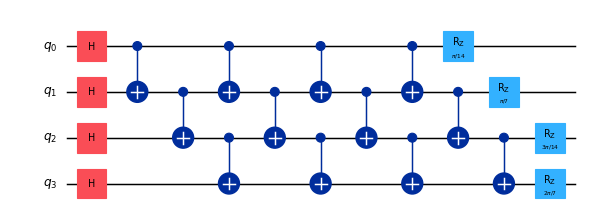

🚀 Démarrage de l'optimisation multi-objectifs...
Paramètres: 4 qubits, 12 gènes, 100 individus, 200 générations

Génération 1/200
Front de Pareto: 6 solutions
Fidélité: 0.1088 ± 0.1247
Profondeur: 4.17 ± 0.69
Coût: 14.17 ± 1.57

Génération 2/200
Front de Pareto: 3 solutions
Fidélité: 0.2488 ± 0.0613
Profondeur: 4.00 ± 0.82
Coût: 13.33 ± 1.25

Génération 3/200
Front de Pareto: 6 solutions
Fidélité: 0.1778 ± 0.1225
Profondeur: 3.83 ± 0.69
Coût: 12.50 ± 1.38

Génération 4/200
Front de Pareto: 7 solutions
Fidélité: 0.1789 ± 0.1107
Profondeur: 3.86 ± 0.83
Coût: 12.57 ± 1.40

Génération 5/200
Front de Pareto: 10 solutions
Fidélité: 0.1651 ± 0.1280
Profondeur: 3.70 ± 0.46
Coût: 12.20 ± 1.47

Génération 6/200
Front de Pareto: 10 solutions
Fidélité: 0.2039 ± 0.1735
Profondeur: 3.60 ± 0.49
Coût: 12.00 ± 1.48

Génération 7/200
Front de Pareto: 10 solutions
Fidélité: 0.2362 ± 0.1477
Profondeur: 3.80 ± 0.60
Coût: 11.90 ± 1.58

Génération 8/200
Front de Pareto: 7 solutions
Fidélité: 0.3578 ± 0.1364


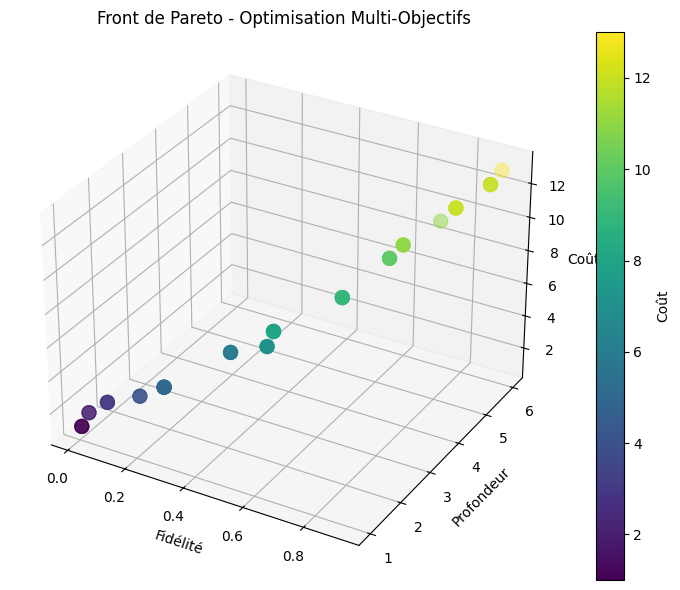

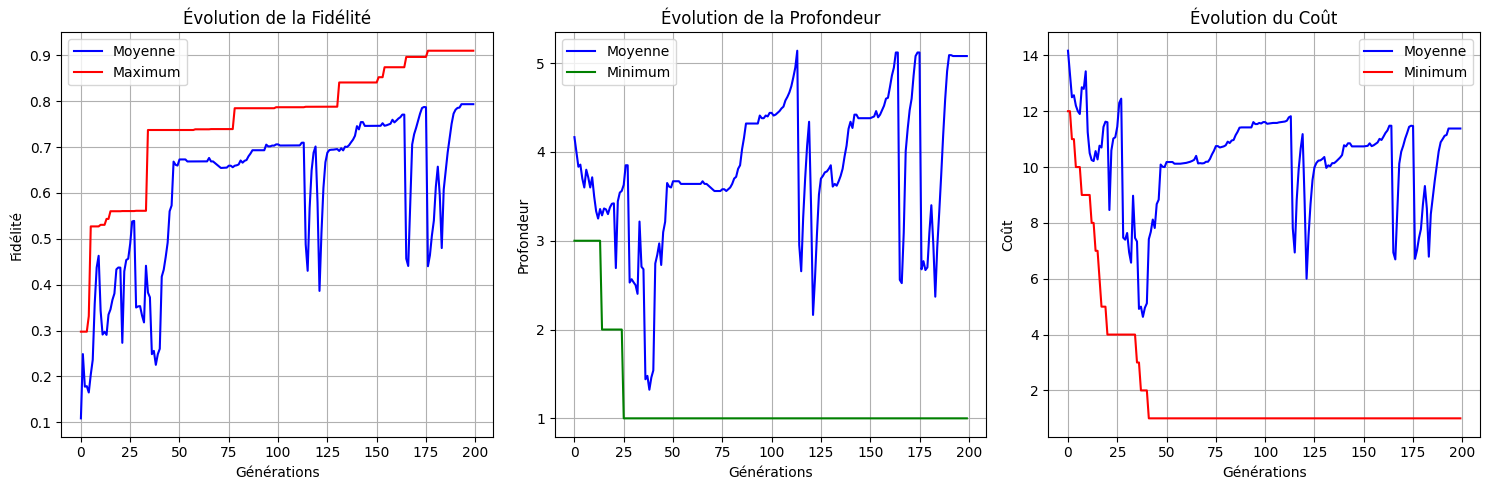


🏆 Meilleur circuit (fidélité):
Fidélité: 0.9130
Profondeur: 6
Coût: 13
Circuit Optimisé : 


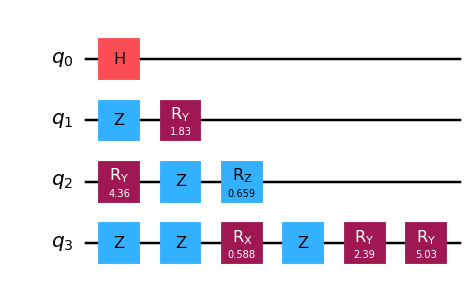

In [23]:
# -------------------- Exécution principal --------------------
if __name__ == "__main__":


    MASTER_SEED = 29
    set_random_seeds(MASTER_SEED)

    # Paramètres
    num_qubits = 4
    num_genes = 12
    pop_size = 100
    generations = 200

    # Créer le circuit cible
    target_unitary = create_target_circuit(num_qubits)

    print("🚀 Démarrage de l'optimisation multi-objectifs...")
    print(f"Paramètres: {num_qubits} qubits, {num_genes} gènes, {pop_size} individus, {generations} générations")

    # Exécuter l'algorithme
    pareto_front, pareto_history = multi_objective_genetic_algorithm(
        num_qubits, num_genes, pop_size, generations, target_unitary,
        mutation_rate=0.1, crossover_rate=0.9
    )

    print(f"\n🎯 Optimisation terminée!")
    print(f"Front de Pareto final: {len(pareto_front)} solutions")

    # Afficher les meilleures solutions
    print("\n📊 Top 5 solutions du front de Pareto:")
    for i, ind in enumerate(pareto_front[:5]):
        fidelity = ind.fitness_values[0]
        depth = -ind.fitness_values[1]
        cost = -ind.fitness_values[2]
        circuit = create_quantum_circuit(ind.chromosome, num_qubits)

        print(f"Solution {i+1}: Fidélité={fidelity:.4f}, Profondeur={depth:.0f}, Coût={cost:.0f}")
        print(f"  Circuit: {len(ind.chromosome)} portes")

    # Visualisations
    plot_pareto_front_3d(pareto_front)
    plot_pareto_evolution(pareto_history)

    # Afficher un circuit optimal
    best_fidelity_ind = max(pareto_front, key=lambda x: x.fitness_values[0])
    best_circuit = create_quantum_circuit(best_fidelity_ind.chromosome, num_qubits)

    print(f"\n🏆 Meilleur circuit (fidélité):")
    print(f"Fidélité: {best_fidelity_ind.fitness_values[0]:.4f}")
    print(f"Profondeur: {-best_fidelity_ind.fitness_values[1]:.0f}")
    print(f"Coût: {-best_fidelity_ind.fitness_values[2]:.0f}")
    print("Circuit Optimisé : ")
    fig, ax = plt.subplots(figsize=(6, 3))
    best_circuit.draw(output='mpl', ax=ax, fold=20)
    plt.tight_layout()
    plt.show()